In [1]:
#### Power System Storage Control
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# !pip install --upgrade openpyxl
# import openpyxl
# print(openpyxl.__version__)

# !conda install openpyxl -y
# !conda install -c conda-forge openpyxl
# wind_data = pd.read_csv("wind_data.xlsx", engine="openpyxl").to_numpy()
wind_data = pd.read_csv("wind_data.csv").to_numpy()
K = pd.read_csv("20200101-20201231 CAISO Average Price.csv").to_numpy()

commit = wind_data[:,1]/100
real = wind_data[:,2]/100
mis = real-commit

Q = 100
e_charge,e_discharge = 0.9,1.1

print('wind data len:',commit.shape[0],'pt len:',K.shape[0])
print(np.min(mis))

### k preprocessing ###
price = K[:,1]
price = price[price>=1e-1]
price = price[price<=100]
np.mean(price), np.std(price)
print(price)


N_price = 10
N_mis = 10
# N_SoC = 51  # 0 ~ 50
# action_set = np.array([-10, -5, 0, 5, 10])  # 可调节
# N_a = len(action_set)
# SoC_max = 50


action_set = np.linspace(-2, 2, 9)     # 精细动作 [-2, ..., 2]
N_a = len(action_set)

SoC_max = 10                          # 电池容量变小，更匹配动作
N_SoC = 21                            # 0.5 单位离散化
# print(N)
# 离散函数
def price_type(p, min_price, max_price, N):
    return int((p - min_price) / ((max_price - min_price + 1e-3) / N_price))

def mis_type(m, min_mis, max_mis, N):
    return int((m - min_mis) / ((max_mis - min_mis + 1e-3) / N_mis))

def soc_type(s, max_SoC, N):
    return max(0, min(N_SoC-1, int(s / ((max_SoC + 1e-3) / N_SoC))))
# 初始化 Q-table 和 reward
Q = np.zeros((N_price, N_mis, N_SoC, N_a))
r = np.zeros_like(Q)

print(np.max(mis[1952:1952+3000]),np.min(mis[1952:1952+3000]),np.mean(np.abs(mis[1952:1952+3000])))
# 假设 price, mis 是你的历史数据
min_price = np.min(price)
max_price = np.max(price)
min_mis = np.min(mis)
max_mis = np.max(mis)

# 生成 reward
Q = np.zeros((N_price, N_mis, N_SoC, N_a))
r = np.zeros_like(Q)

for i in range(N_price):
    for j in range(N_mis):
        for k in range(N_SoC):
            for a in range(N_a):
                price_val = min_price + (max_price - min_price) * (i + 0.5) / N_price
                mis_val = min_mis + (max_mis - min_mis) * (j + 0.5) / N_mis
                soc_val = k * (SoC_max / (N_SoC - 1))

                act = action_set[a]
                act = np.clip(act, -soc_val, SoC_max - soc_val)

                net_mis = mis_val + act
                cost = max(0, -net_mis) * price_val
                r[i, j, k, a] = cost



wind data len: 52403 pt len: 105293
-8.76
[24.31731 25.58519 24.656673 ... 30.342 30.347296 30.347296]
9.119999999999997 -6.83 1.2920600000000055


In [2]:
gamma = 0.95
for it in range(100):  # value iteration
    Q_new = np.copy(Q)
    for i in range(N_price):
        for j in range(N_mis):
            for k in range(N_SoC):
                for a in range(N_a):
                    soc = k * (SoC_max / (N_SoC - 1))
                    act = action_set[a]
                    act = np.clip(act, -soc, SoC_max - soc)
                    soc_new = soc + act
                    soc_new = np.clip(soc_new, 0, SoC_max)

                    k_new = soc_type(soc_new, SoC_max, N_SoC)
                    Q_new[i, j, k, a] = r[i, j, k, a] + gamma * np.min(Q[i, j, k_new, :])
    Q = Q_new


In [3]:
def calculate_cost_q(Q):
    soc = 5  # 初始 SoC
    cost_list = []
    soc_list = []

    for t in range(1952, 1952 + 3000):
        p = price[t]
        m = mis[t]

        i = price_type(p, min_price, max_price, N_price)
        j = mis_type(m, min_mis, max_mis, N_mis)
        k = soc_type(soc, SoC_max, N_SoC)

        a_idx = np.argmin(Q[i, j, k, :])
        act = action_set[a_idx]
        act = np.clip(act, -soc, SoC_max - soc)

        net_mis = m + act
        cost = max(0, -net_mis) * p

        soc = np.clip(soc + act, 0, SoC_max)

        cost_list.append(cost)
        soc_list.append(soc)

    return np.cumsum(cost_list), soc_list



In [4]:
from itertools import product

from itertools import product

def mpc_optimize(price_seq, mis_seq, SoC_now, k, Q):
    best_cost = np.inf
    best_seq = None

    for action_seq in product(action_set, repeat=k):
        soc = SoC_now
        total_cost = 0

        for t in range(k):
            act = np.clip(action_seq[t], -soc, SoC_max - soc)
            net_mis = mis_seq[t] + act
            step_cost = max(0, -net_mis) * price_seq[t]

            soc = np.clip(soc + act, 0, SoC_max)
            total_cost += step_cost

        # terminal value
        i = price_type(price_seq[-1], min_price, max_price, N_price)
        j = mis_type(mis_seq[-1], min_mis, max_mis, N_mis)
        k_ = soc_type(soc, SoC_max, N_SoC)
        total_cost += np.min(Q[i, j, k_, :])

        if total_cost < best_cost:
            best_cost = total_cost
            best_seq = action_seq

    return best_seq[0]

def calculate_cost_mpc(Q, k):
    soc = 5
    cost_list = []
    soc_list = []

    for t in range(1952, 1952 + 3000):
        price_seq = price[t:t + k]
        mis_seq = mis[t:t + k]

        act = mpc_optimize(price_seq, mis_seq, soc, k, Q)
        act = np.clip(act, -soc, SoC_max - soc)

        net_mis = mis[t] + act
        cost = max(0, -net_mis) * price[t]

        soc = np.clip(soc + act, 0, SoC_max)
        cost_list.append(cost)
        soc_list.append(soc)

    return np.cumsum(cost_list), soc_list

def calculate_cost_predict_k_step(Q, k):
    soc = 5
    cost_list = []
    soc_list = []

    T_total = 1952 + 3000
    t = 1952

    while t < T_total:
        price_seq = price[t:t + k]
        mis_seq = mis[t:t + k]

        # 防止溢出
        if len(price_seq) < k or len(mis_seq) < k:
            break

        # 一次性规划出完整 K 步动作序列
        best_cost = np.inf
        best_action_seq = None

        for action_seq in product(action_set, repeat=k):
            soc_sim = soc
            total_cost = 0

            for step in range(k):
                act = np.clip(action_seq[step], -soc_sim, SoC_max - soc_sim)
                net_mis = mis_seq[step] + act
                cost = max(0, -net_mis) * price_seq[step]
                soc_sim = np.clip(soc_sim + act, 0, SoC_max)
                total_cost += cost

            if total_cost < best_cost:
                best_cost = total_cost
                best_action_seq = action_seq

        # 执行整个 K 步动作序列
        for step in range(k):
            if t >= T_total:
                break
            act = np.clip(best_action_seq[step], -soc, SoC_max - soc)
            net_mis = mis[t] + act
            cost = max(0, -net_mis) * price[t]
            soc = np.clip(soc + act, 0, SoC_max)

            cost_list.append(cost)
            soc_list.append(soc)
            t += 1

    return np.cumsum(cost_list), soc_list



In [5]:
def calculate_cost_predict_k_step_with_noise(Q, k, price, mis,
                                              action_set, SoC_max,
                                              N_price, N_mis, N_SoC,
                                              min_price, max_price,
                                              min_mis, max_mis,
                                              σ_p=0.0, σ_m=0.0,
                                              start=1952, length=3000):
    def price_type(p):
        return int((p - min_price) / ((max_price - min_price + 1e-3) / N_price))
    def mis_type(m):
        return int((m - min_mis) / ((max_mis - min_mis + 1e-3) / N_mis))
    def soc_type(s):
        return max(0, min(N_SoC - 1, int(s / ((SoC_max + 1e-3) / N_SoC))))

    soc = 5
    cost_list = []
    T_total = start + length
    t = start

    while t < T_total:
        # 添加噪声预测
        epsilon_p = np.random.normal(0, σ_p, k)
        epsilon_m = np.random.normal(0, σ_m, k)

        price_pred = price[t:t + k] * (1 + epsilon_p)
        mis_pred = mis[t:t + k] * (1 + epsilon_m)

        if len(price_pred) < k or len(mis_pred) < k:
            break

        best_cost = np.inf
        best_action_seq = None
        for action_seq in product(action_set, repeat=k):
            soc_sim = soc
            total_cost = 0
            for step in range(k):
                act = np.clip(action_seq[step], -soc_sim, SoC_max - soc_sim)
                net_mis = mis_pred[step] + act
                cost = max(0, -net_mis) * price_pred[step]
                soc_sim = np.clip(soc_sim + act, 0, SoC_max)
                total_cost += cost
            if total_cost < best_cost:
                best_cost = total_cost
                best_action_seq = action_seq

        for step in range(k):
            if t >= T_total:
                break
            act = np.clip(best_action_seq[step], -soc, SoC_max - soc)
            net_mis = mis[t] + act
            cost = max(0, -net_mis) * price[t]
            soc = np.clip(soc + act, 0, SoC_max)
            cost_list.append(cost)
            t += 1

    return np.cumsum(cost_list)

1
48892.37639566003 51439.23771103997
2
48345.15438849001 51439.23771103997
3
48062.39022319002 51439.23771103997
4
47669.20262511006 51439.23771103997


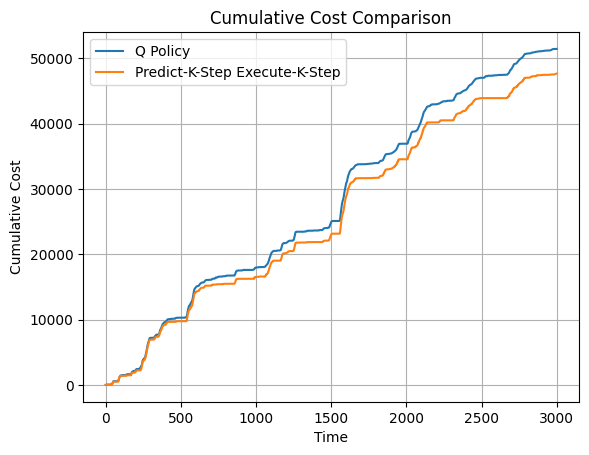

Final Cost (Predict-K-Step): 47669.20262511006


In [6]:
cumsum_q, soc_q = calculate_cost_q(Q)
cumsum_predict_list = []
soc_predict_list = []
for k in range(1,5):
    print(k)
    cumsum_predict = calculate_cost_predict_k_step_with_noise(
            Q, k, price, mis,
            action_set, SoC_max,
            N_price, N_mis, N_SoC,
            min_price, max_price,
            min_mis, max_mis,
            σ_p=0, σ_m=0,
            length=3000
        )
    cumsum_predict_list.append(cumsum_predict)
    # soc_predict_list.append(soc_predict)
    print(cumsum_predict[-1],cumsum_q[-1])
# 比较
plt.plot(cumsum_q, label="Q Policy")
plt.plot(cumsum_predict, label="Predict-K-Step Execute-K-Step")
plt.legend()
plt.title("Cumulative Cost Comparison")
plt.xlabel("Time")
plt.ylabel("Cumulative Cost")
plt.grid(True)
plt.show()

print("Final Cost (Predict-K-Step):", cumsum_predict[-1])

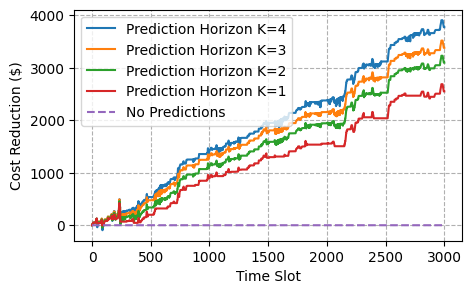

In [7]:
cumsum_predict_1 = np.array(cumsum_q)-np.array(cumsum_predict_list[0])
cumsum_predict_2 = np.array(cumsum_q)-np.array(cumsum_predict_list[1])
cumsum_predict_3 = np.array(cumsum_q)-np.array(cumsum_predict_list[2])
cumsum_predict_4 = np.array(cumsum_q)-np.array(cumsum_predict_list[3])
cumsum_0 = np.array(cumsum_q)-np.array(cumsum_q)
plt.style.use('default')
plt.figure(figsize=[5,3])
plt.grid(True, which='major', axis='both', linestyle='--')
plt.plot(cumsum_predict_4, label="Prediction Horizon K=4")
plt.plot(cumsum_predict_3, label="Prediction Horizon K=3")
plt.plot(cumsum_predict_2, label="Prediction Horizon K=2")
plt.plot(cumsum_predict_1, label="Prediction Horizon K=1")




plt.plot(cumsum_0, ls='--', label="No Predictions")
plt.legend()
# plt.title("Cumulative Cost Comparison")
plt.xlabel("Time Slot")
plt.ylabel("Cost Reduction (\$)")
plt.grid(True)
plt.savefig('Performance_Storage_Control.pdf', bbox_inches='tight')
plt.show()

In [39]:
import numpy as np
from itertools import product




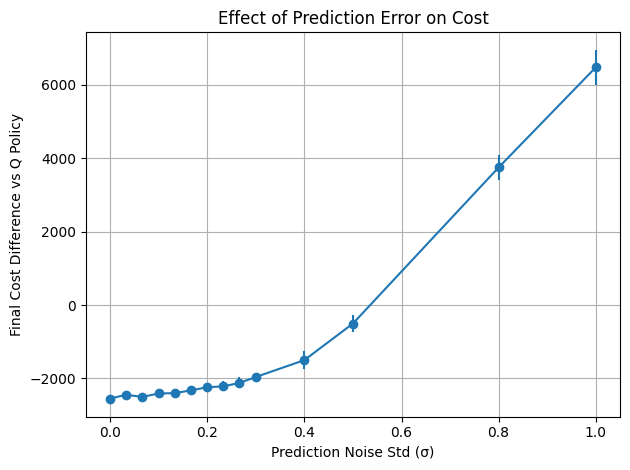

In [8]:
import matplotlib.pyplot as plt

noise_levels = [0.0, 0.033, 0.066, 0.1, 0.133, 0.166, 0.2, 0.233, 0.266, 0.3,0.4,0.5,0.8,1]
k = 1
runs_per_level = 5
gap_means = []
gap_stds = []

# Baseline Q performance
cumsum_q, _ = calculate_cost_q(Q)
baseline = cumsum_q[:3000]

for σ in noise_levels:
    gaps = []
    for _ in range(runs_per_level):
        cumsum_pred = calculate_cost_predict_k_step_with_noise(
            Q, k, price, mis,
            action_set, SoC_max,
            N_price, N_mis, N_SoC,
            min_price, max_price,
            min_mis, max_mis,
            σ_p=σ, σ_m=σ,
            length=3000
        )
        gap = cumsum_pred[-1] - baseline[-1]
        gaps.append(gap)
    gap_means.append(np.mean(gaps))
    gap_stds.append(np.std(gaps))

# Plot result
plt.errorbar(noise_levels, gap_means, yerr=gap_stds, fmt='-o')
plt.title("Effect of Prediction Error on Cost")
plt.xlabel("Prediction Noise Std (σ)")
plt.ylabel("Final Cost Difference vs Q Policy")
plt.grid(True)
plt.tight_layout()
plt.show()



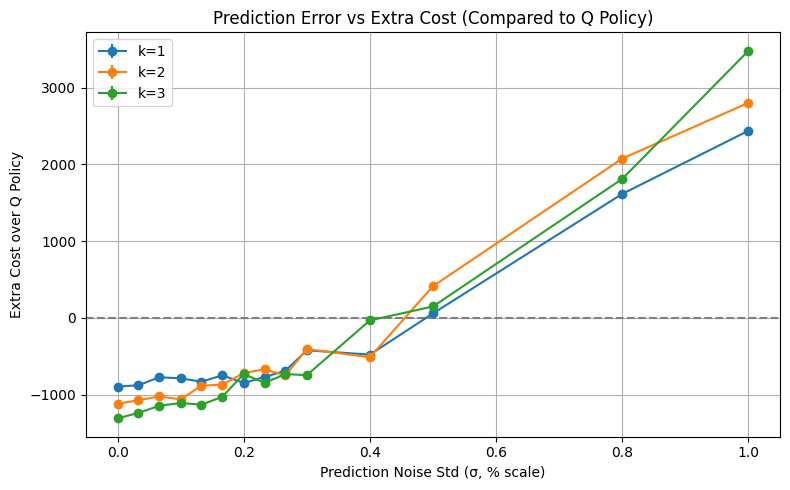

In [11]:
import matplotlib.pyplot as plt

noise_levels = [0.0, 0.033, 0.066, 0.1, 0.133, 0.166, 0.2, 0.233, 0.266, 0.3,0.4,0.5,0.8,1]
runs_per_level = 1
eval_length = 1000
k_values = [1, 2, 3]

# Baseline Q policy
cumsum_q, _ = calculate_cost_q(Q)
baseline = cumsum_q[:eval_length]

# 存储每个k下的gap均值和标准差
gap_means_by_k = {}
gap_stds_by_k = {}

for k in k_values:
    gap_means = []
    gap_stds = []
    for σ in noise_levels:
        gaps = []
        for _ in range(runs_per_level):
            cumsum_pred = calculate_cost_predict_k_step_with_noise(
                Q, k, price, mis,
                action_set, SoC_max,
                N_price, N_mis, N_SoC,
                min_price, max_price,
                min_mis, max_mis,
                σ_p=σ, σ_m=σ,  # 使用百分比误差
                length=eval_length
            )
            gap = cumsum_pred[-1] - baseline[-1]
            gaps.append(gap)
        gap_means.append(np.mean(gaps))
        gap_stds.append(np.std(gaps))
    gap_means_by_k[k] = gap_means
    gap_stds_by_k[k] = gap_stds

# ✅ 绘图：不同 k 下的误差曲线
plt.figure(figsize=(8, 5))
for k in k_values:
    plt.errorbar(noise_levels, gap_means_by_k[k], yerr=gap_stds_by_k[k], fmt='-o', label=f'k={k}')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Prediction Error vs Extra Cost (Compared to Q Policy)")
plt.xlabel("Prediction Noise Std (σ, % scale)")
plt.ylabel("Extra Cost over Q Policy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


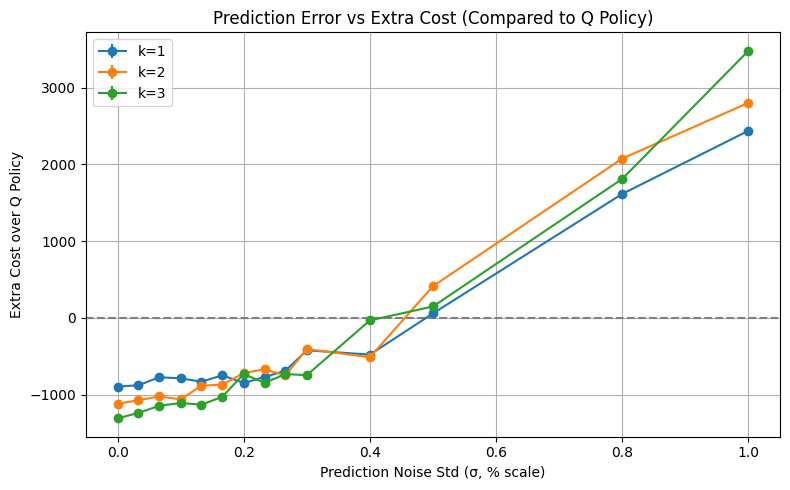

In [12]:
plt.figure(figsize=(8, 5))
for k in k_values:
    plt.errorbar(noise_levels, gap_means_by_k[k], yerr=gap_stds_by_k[k], fmt='-o', label=f'k={k}')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Prediction Error vs Extra Cost (Compared to Q Policy)")
plt.xlabel("Prediction Noise Std (σ, % scale)")
plt.ylabel("Extra Cost over Q Policy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

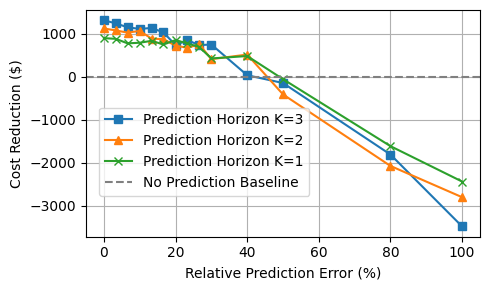

In [14]:
# plt.figure(figsize=(8, 5))
plt.style.use('default')
plt.figure(figsize=[5, 3])

# 按顺序画 K=3,2,1
k_order = [ 3, 2, 1]
markers = {'1': 'x', '2': '^', '3': 's'}

for k in k_order:
    mean = -np.array(gap_means_by_k[k])
    std = np.array(gap_stds_by_k[k])
    plt.plot(np.array(noise_levels)*100, mean, marker=markers[str(k)], label=f'Prediction Horizon K={k}')
    plt.fill_between(np.array(noise_levels)*100, mean - std*2, mean + std*2, alpha=0.2)

# baseline
plt.axhline(0, color='gray', linestyle='--', label="No Prediction Baseline")

# 轴和图例
plt.xlabel("Relative Prediction Error (%)")
plt.ylabel("Cost Reduction ($)")
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.6), ncol=1, frameon=True)
plt.tight_layout()
plt.savefig('Performance_Storage_Control_Error.pdf', bbox_inches='tight')
plt.show()

